# **Linear Regression Project**
We are going to analyze the factors that affect employee salaries in the UAE and predict salaries based on input features. This is a common application in salary prediction models, helping job seekers, companies, and policymakers understand salary determinants.



In [138]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.api import OLS, add_constant

#Load the Dataset
url="https://drive.google.com/uc?id=1csiDOrRwE6ONbF6Iov349eaGmHdV99kT"
data=pd.read_csv(url)

#Preview of the Dataset
data.head()

,Unnamed: 0,YearsExperience,EducationLevel,JobRole,Industry,WorkingHoursPerWeek,Salary,Country
0,0,7,Master,Mid-Level,Manufaturing,39,120814,UAE
1,1,20,PhD,Junior,IT,49,181418,UAE
2,2,15,PhD,Junior,Healthcare,59,152492,UAE
3,3,11,PhD,Mid-Level,Manufaturing,36,147853,UAE
4,4,8,NaN,Senior,Finance,44,136932,UAE


## Data Context

* YearsExperience: Number of years an employee has worked.

* Employees with more experience generally earn higher salaries.

* JobRole: The type of job position.

* Industry: The industry sector of employment.

* WorkingHours: Number of hours worked per week.

* Salary (Target Variable): The annual salary of the employee in AED (United Arab Emirates Dirham).
  
  -> This is the dependent variable we aim to predict based on the other features.

# **Data Pre-Processing**

In [139]:
#Missing values checking
data.isnull().sum()

,0
Unnamed: 0,0
YearsExperience,0
EducationLevel,61
JobRole,0
Industry,0
WorkingHoursPerWeek,0
Salary,0
Country,0


In [140]:
#Missing values handling
data['EducationLevel']=data['EducationLevel'].fillna(data['EducationLevel'].mode()[0]) #imputation with the mode for a categorical variable

In [141]:
#Rechecking if we still have missing value in the dataset

sum(data.isnull().sum())

0

In [142]:
#Duplicates checking

sum(data.duplicated())

0

# **Exploration Data Analysis (EDA)**

In [143]:
#information on the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           200 non-null    int64 
 1   YearsExperience      200 non-null    int64 
 2   EducationLevel       200 non-null    object
 3   JobRole              200 non-null    object
 4   Industry             200 non-null    object
 5   WorkingHoursPerWeek  200 non-null    int64 
 6   Salary               200 non-null    int64 
 7   Country              200 non-null    object
dtypes: int64(4), object(4)
memory usage: 12.6+ KB


In [144]:
#columns detection
data.columns

Index(['Unnamed: 0', 'YearsExperience', 'EducationLevel', 'JobRole',
       'Industry', 'WorkingHoursPerWeek', 'Salary', 'Country'],
      dtype='object')

In [145]:
#shape of the dataset
data.shape

(200, 8)

In [146]:
#statistical summary
data.describe()

,Unnamed: 0,YearsExperience,WorkingHoursPerWeek,Salary
count,200.000000,200.000000,200.000000,200.000000
mean,99.500000,9.860000,47.225000,128950.400000
std,57.879185,5.815453,7.511089,38257.371006
min,0.000000,1.000000,35.000000,53877.000000
25%,49.750000,5.000000,40.000000,100313.500000
50%,99.500000,9.000000,48.000000,128123.000000
75%,149.250000,15.000000,53.000000,158537.500000
max,199.000000,20.000000,59.000000,213889.000000


In [147]:
#numerical columns extraction
numerical_columns=data.select_dtypes(include='number').columns
numerical_columns

Index(['Unnamed: 0', 'YearsExperience', 'WorkingHoursPerWeek', 'Salary'], dtype='object')

In [148]:
#categorical columns extraction
categorical_columns=data.select_dtypes(include=object).columns
categorical_columns

Index(['EducationLevel', 'JobRole', 'Industry', 'Country'], dtype='object')

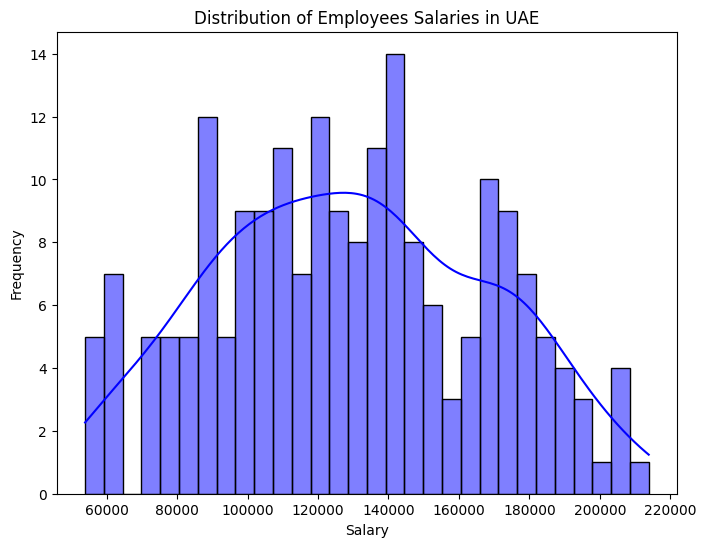

In [149]:
# Visualizing the target variable (Salary)
plt.figure(figsize=(8, 6))
sns.histplot(data['Salary'], kde=True, bins=30, color='blue')
plt.title('Distribution of Employees Salaries in UAE')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

# **Data Transformation**

In [150]:
# Ecoding categorical variable: EducationLevel
data['EducationLevel']=data['EducationLevel'].map({'Bachelor':1,
                                 'Master':2,
                                 'PhD':3
                                 })
data['EducationLevel'].value_counts().to_dict()

{1: 109, 3: 46, 2: 45}

In [151]:
# Ecoding categorical variable: Industry
data['Industry']=data['Industry'].map({'IT':1,
                                 'Finance':2,
                                 'Healthcare':3,
                                 'Manufaturing':4
                                 })
data['Industry'].value_counts().to_dict()

{1: 59, 4: 52, 3: 45, 2: 44}

In [152]:
# Ecoding categorical variable: JobRole
data['JobRole']=data['JobRole'].map({'Junior':1,
                                 'Mid-Level':2,
                                 'Senior':3
                                 })
data['JobRole'].value_counts().to_dict()

{1: 77, 2: 68, 3: 55}

In [153]:
#change the name of "Unnamed: 0" column to "ID"
data=data.rename(columns={'Unnamed: 0':'ID'})
data.columns

Index(['ID', 'YearsExperience', 'EducationLevel', 'JobRole', 'Industry',
       'WorkingHoursPerWeek', 'Salary', 'Country'],
      dtype='object')

In [154]:
#change the order of columns so that the dependent variable (Salary) is the last column  (for better readability and separation between features)
data=data[['ID', 'YearsExperience', 'EducationLevel', 'JobRole', 'Industry',
       'WorkingHoursPerWeek','Country', 'Salary']]
data.head(1)

,ID,YearsExperience,EducationLevel,JobRole,Industry,WorkingHoursPerWeek,Country,Salary
0,0,7,2,2,4,39,UAE,120814


In [155]:
#Drop the Country column to avoid redudancy (as the research focuses only on UAE )
data=data.drop(columns='Country')

In [156]:
data.columns

Index(['ID', 'YearsExperience', 'EducationLevel', 'JobRole', 'Industry',
       'WorkingHoursPerWeek', 'Salary'],
      dtype='object')

# **Performing Linear Regression**

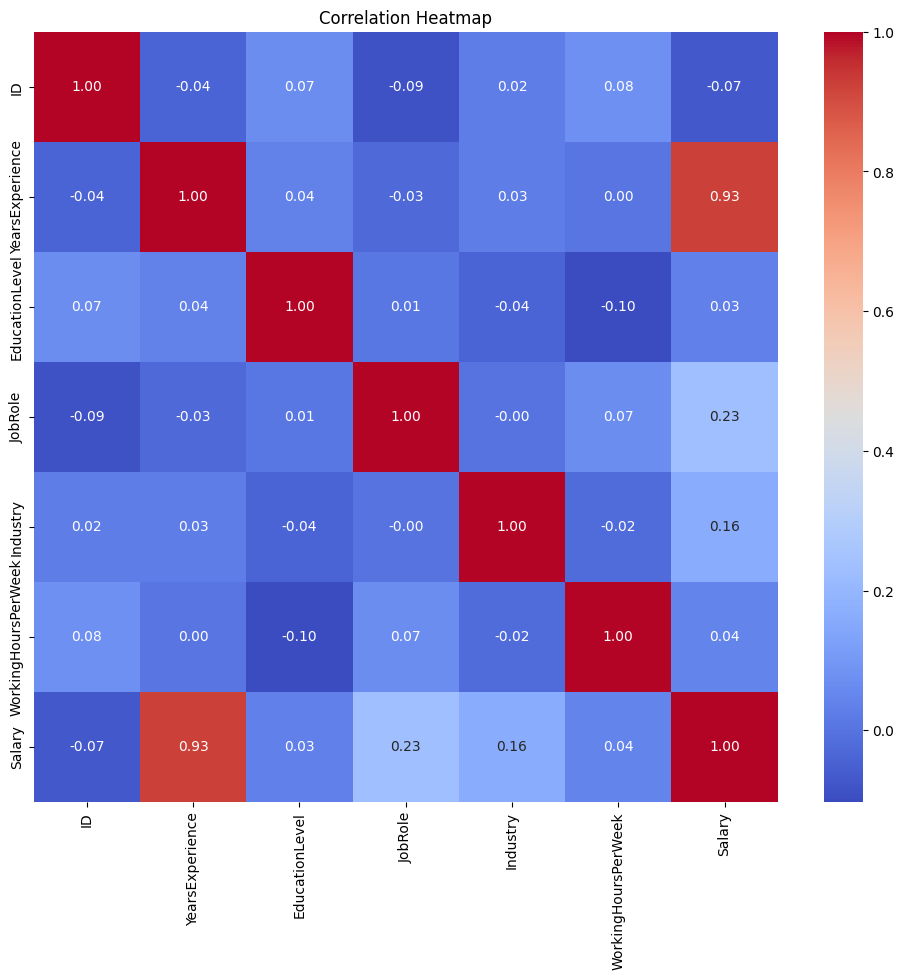

In [157]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [158]:
# Selecting features for regression
# Use only numerical columns and drop those with very low correlation with the target
correlation_with_target = data.corr()['Salary'].sort_values(ascending=False)
print(correlation_with_target)

Salary                 1.000000
YearsExperience        0.925222
JobRole                0.229405
Industry               0.164306
WorkingHoursPerWeek    0.043510
EducationLevel         0.032183
ID                    -0.069151
Name: Salary, dtype: float64


In [159]:
# Selecting top correlated features for regression
selected_features = correlation_with_target[correlation_with_target.abs() > 0.5].index.tolist()
selected_features.remove('Salary')  # Exclude the target variable
print("Selected Features:", selected_features)

Selected Features: ['YearsExperience']


# **Fitting a Simple Linear Regression (SLR) Model**
Using **statsmodels** library for statistical analysis and hypothesis testing

In [160]:
# Independent and dependent variables
import statsmodels.api as sm

X = data['YearsExperience']
y = data['Salary']

# Add a constant for the intercept
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Prediction:
predictions = model.predict(X)
residuals = y - predictions



# **Assumptions of Linear Regression**

* **Linearity**

The relationship between predictors and the target variable should be linear.

* **Independence of Errors**

Residuals should be independent of each other (no autocorrelation).

* **Homoscedasticity**

The variance of residuals should be constant across all levels of the independent variables.

* **Normality of Residuals**

The residuals should be approximately normally distributed.

* **No Multicollinearity**

Independent variables should not be highly correlated with each other.

## Linearity

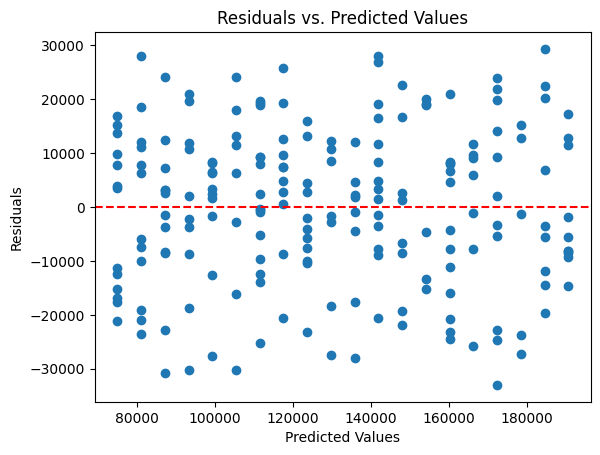

In [161]:
#Visualizing the scatter plot YearsExperience (Explanatory Variable) vs.Salary (Target Variable)
plt.scatter(predictions, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values")
plt.show()

## Independence of Errors
Our data is not collected over time. Therefore, it is not necessary to perform the Durbin-Waston test. However, we can check for the independence assumption using the **residual plot** plotted above.

## Homoscedasticity
In addition to the scatter plot, we will perform **Breusch-Pagan test**.

* **Null Hypothesis (H₀)**: Homoscedasticity (errors have constant variance).

* **Alternative Hypothesis (H₁)**: Heteroscedasticity (errors have non-constant variance).

In [162]:
#Performing Breusch-Pagan test (Significance level of 5%)
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(residuals, X)
print("Breusch-Pagan p-value:", bp_test[1])

Breusch-Pagan p-value: 0.4508015439567291


A Breusch-Pagan p-value of **0.451** indicates that we fail to reject the null hypothesis of homoscedasticity. This means there is no significant evidence of heteroscedasticity in the model, and the residuals likely have **constant variance**.

## Normality of Residuals
**Test:** Check residuals with a histogram or Q-Q plot.
**Test:** Perform the Shapiro-Wilk test

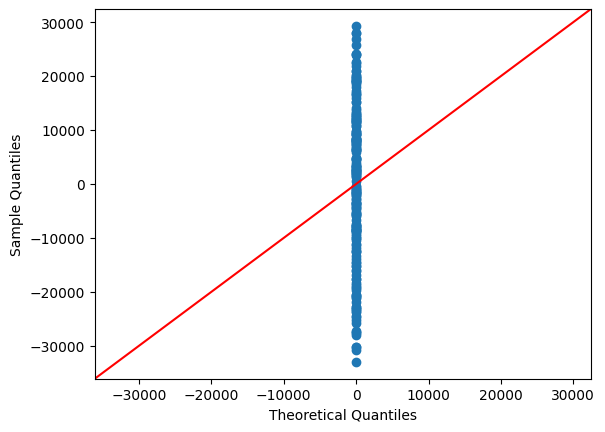

In [163]:
#Visualizing Residuals Q-Q plot
sm.qqplot(residuals, line='45')
plt.show()

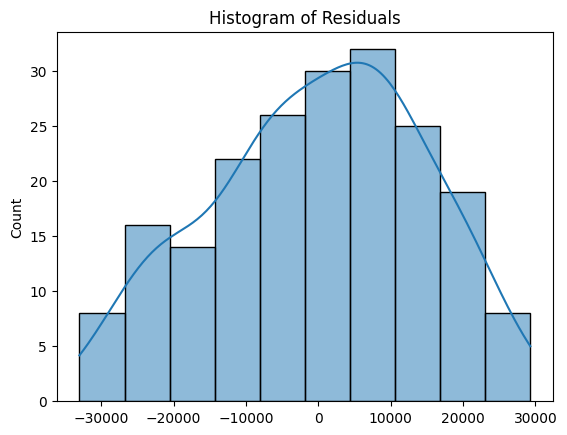

In [164]:
#Visualizing Residuals Histogram
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.show()

**Statistical Test**: Jarque_bera

**Null Hypothesis (H₀)**: The data is normally distributed.

**Alternative Hypothesis (H₁)**: The data is not normally distributed.

In [182]:
from scipy.stats import jarque_bera

# Perform Jarque-Bera test
jb_stat, jb_p_value = jarque_bera(residuals)
print("Jarque-Bera Test Statistic:", jb_stat)
print("p-value:", jb_p_value)

Jarque-Bera Test Statistic: 5.758122293148729
p-value: 0.05618748989613618


p-value > 0.05: Reject the null hypothesis of normality

## Multicollinearity
**Test**: Calculate the **Variance Inflation Factor (VIF)**. VIF > 5 indicates multicollinearity.

In [166]:
#Performing the VIF test
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

          Variable       VIF
0            const  3.889107
1  YearsExperience  1.000000


## Modeling
Using **Sickit-Learn** Library for machine learning and predictions.

In [167]:
# Splitting data into training and testing sets
X = data[selected_features]
y = data['Salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [168]:
# Building and evaluating a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

#  **Model Evaluation:**  
We will be using **MSE** and **R-squared** evaluation metrics.

In [169]:
#1st Method: Mean Squared Error (MSE)

# Predictions on training and testing data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Compute MSE
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

Train MSE: 214295628.1490957
Test MSE: 191466791.33573407


In [170]:
# 2nd Method: R-squared
#Compute R² scores
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train R²:", train_r2)
print("Test R²:", test_r2)


Train R²: 0.8531535859592128
Test R²: 0.865402107780437


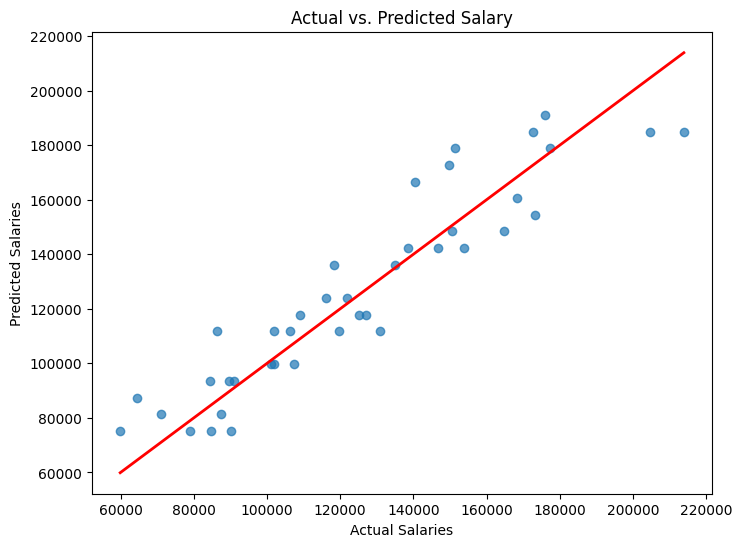

In [171]:
#Prediction
y_pred = model.predict(X_test)

## Visualizing actual vs. predicted prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.title('Actual vs. Predicted Salary')
plt.xlabel('Actual Salaries')
plt.ylabel('Predicted Salaries')
plt.show()

# **Ordinary Least Squares (OLS) Summary**

In [172]:
# Running an OLS regression for more detailed diagnostics
X_train_with_const = add_constant(X_train)
ols_model = OLS(y_train, X_train_with_const).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                     918.0
Date:                Wed, 29 Jan 2025   Prob (F-statistic):           1.04e-67
Time:                        19:46:20   Log-Likelihood:                -1761.7
No. Observations:                 160   AIC:                             3527.
Df Residuals:                     158   BIC:                             3533.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            6.912e+04   2322.361     

In [173]:
# Interpreting feature importance
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_})
coefficients

,Feature,Coefficient
0,YearsExperience,6095.175178


# **Model Transformations**

## Stepwise Regression: Mallow's Cp criterion

In [176]:
# Function to calculate Mallow's Cp
def calculate_cp(model, X, y):
    n = len(y)
    p = X.shape[1]
    rss = np.sum((model.predict(X) - y) ** 2)
    mse = rss / (n - p)  # Mean Squared Error
    cp = (rss / mse) - (n - 2 * p)
    return cp

# Forward stepwise selection function
def forward_stepwise(X, y):
    X_selected = pd.DataFrame()
    remaining_features = X.columns.tolist()
    selected_features = []

    best_cp = float('inf')
    best_model = None

    # Iterate through features to add the best feature based on Mallow's Cp
    while remaining_features:
        cp_values = []
        for feature in remaining_features:
            X_temp = X[selected_features + [feature]]
            X_temp = sm.add_constant(X_temp)  # Add constant for intercept
            model = sm.OLS(y, X_temp).fit()
            cp = calculate_cp(model, X_temp, y)
            cp_values.append((feature, cp))

        # Select the feature with the lowest Cp value
        best_feature, best_cp_value = min(cp_values, key=lambda x: x[1])

        if best_cp_value < best_cp:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
            best_cp = best_cp_value
            best_model = sm.OLS(y, sm.add_constant(X[selected_features])).fit()
        else:
            break  # Stop when no improvement in Cp

    return best_model, selected_features

# Example usage with your data
X = data[['YearsExperience', 'EducationLevel', 'JobRole', 'Industry', 'WorkingHoursPerWeek']]  # Example independent variables
y = data['Salary']

best_model, selected_features = forward_stepwise(X, y)

# Display the best model's summary and selected features
print(best_model.summary())
print(f"Selected Features: {selected_features}")


                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     11.00
Date:                Wed, 29 Jan 2025   Prob (F-statistic):            0.00108
Time:                        19:46:20   Log-Likelihood:                -2388.3
No. Observations:                 200   AIC:                             4781.
Df Residuals:                     198   BIC:                             4787.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.084e+05   6736.850     16.090      0.0

## Multiple Regression Model (MLR)

In [177]:
# Add YearsExperience along with JobRole
X_new = data[['JobRole', 'YearsExperience']]
X_new = sm.add_constant(X_new)  # Add constant for intercept
MLR_model = sm.OLS(y, X_new).fit()

# Display the summary
print(MLR_model.summary())


                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     1152.
Date:                Wed, 29 Jan 2025   Prob (F-statistic):          1.94e-109
Time:                        19:46:20   Log-Likelihood:                -2139.6
No. Observations:                 200   AIC:                             4285.
Df Residuals:                     197   BIC:                             4295.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            4.558e+04   2368.200     

After adding JobRole, the Adj. R-squared **improved** from 0.852 in SLR to  0.920 in MLR.

## Adding an Interaction Term

In [178]:
# Create interaction term between JobRole and YearsExperience
data['JobRole_YearsExperience'] = data['JobRole'] * data['YearsExperience']
X_interaction = data[['JobRole', 'YearsExperience', 'JobRole_YearsExperience']]
X_interaction = sm.add_constant(X_interaction)
model_interaction = sm.OLS(y, X_interaction).fit()

# Display the summary
print(model_interaction.summary())


                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.922
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     767.6
Date:                Wed, 29 Jan 2025   Prob (F-statistic):          4.94e-108
Time:                        19:46:20   Log-Likelihood:                -2139.2
No. Observations:                 200   AIC:                             4286.
Df Residuals:                     196   BIC:                             4300.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    4

After adding the interaction term JobRole_YearsExperience the Adj. R-squared remained the same. However, the **model's overall significance** indicated by F-statistic **decreased** from 1152. in MLR to 767.6.

In [184]:
#Multiplicative Model
# Create interaction term between JobRole and YearsExperience
data['JobRole_YearsExperience'] = data['JobRole'] * data['YearsExperience']
X_interaction = data[ 'JobRole_YearsExperience']
X_interaction = sm.add_constant(X_interaction)
model_mult = sm.OLS(y, X_interaction).fit()

# Display the summary
print(model_mult.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     521.4
Date:                Wed, 29 Jan 2025   Prob (F-statistic):           2.26e-57
Time:                        21:01:19   Log-Likelihood:                -2264.7
No. Observations:                 200   AIC:                             4533.
Df Residuals:                     198   BIC:                             4540.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    8

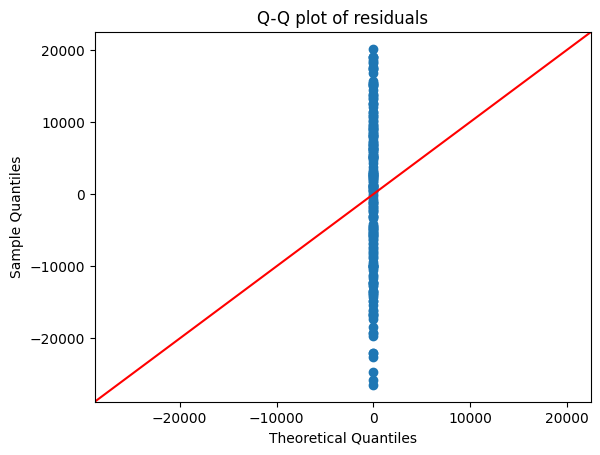

In [179]:
#Normality rechecking
new_residuals = MLR_model.resid
# Q-Q plot
sm.qqplot(new_residuals, line ='45')
plt.title('Q-Q plot of residuals')
plt.show()


In [180]:
from scipy.stats import jarque_bera

# Perform Jarque-Bera test
jb_stat, jb_p_value = jarque_bera(new_residuals)
print("Jarque-Bera Test Statistic:", jb_stat)
print("p-value:", jb_p_value)


Jarque-Bera Test Statistic: 5.5524399295797995
p-value: 0.06227345890238349


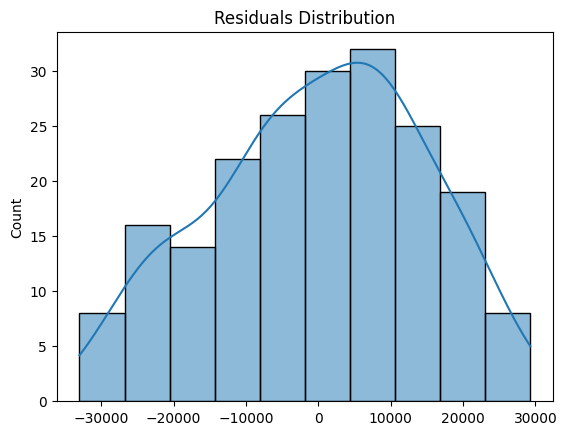

In [181]:
# Histogram of residuals
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')
plt.show()